# COVID - 19 SMALL DATASET

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

### Load the covid_19_data.csv dataset using pandas and display the first 5 rows.

In [13]:
data = pd.read_csv(r"D:\Downloads\covid_19_data.csv")
data
data.head()

,Date,State,Region,Confirmed,Deaths,Recovered
0,4/29/2020,NaN,Afghanistan,1939,60,252
1,4/29/2020,NaN,Albania,766,30,455
2,4/29/2020,NaN,Algeria,3848,444,1702
3,4/29/2020,NaN,Andorra,743,42,423
4,4/29/2020,NaN,Angola,27,2,7


### Create a new column called Active Cases using the formula:
### Active = Confirmed − Deaths − Recovered.

In [84]:
data['Active'] = data['Confirmed'] - data['Deaths'] - data['Recovered']
data.head()

,Date,State,Region,Confirmed,Deaths,Recovered,Active
0,4/29/2020,NaN,Afghanistan,1939,60,252,1627
1,4/29/2020,NaN,Albania,766,30,455,281
2,4/29/2020,NaN,Algeria,3848,444,1702,1702
3,4/29/2020,NaN,Andorra,743,42,423,278
4,4/29/2020,NaN,Angola,27,2,7,18


### Find the country/region with the highest number of confirmed cases.

In [86]:
data.groupby('Region').Confirmed.sum().sort_values(ascending=False).head(1)

Region
US    1039909
Name: Confirmed, dtype: int64

### Check the dataset for missing values and display the total missing values in each column.

In [26]:
data.isnull().sum()

Date           0
State        181
Region         0
Confirmed      0
Deaths         0
Recovered      0
dtype: int64

### Sort the dataset by Confirmed cases in descending order and display the top 10 records.

In [28]:
data.Confirmed.sort_values(ascending=False).head(10)

265    299691
153    236899
80     203591
168    165221
57     165093
61     161539
167    117589
262    116365
134     99399
76      93657
Name: Confirmed, dtype: int64

### Filter and display all records where Deaths are greater than 1000.

In [88]:
data[data['Deaths']>1000][['Region','Deaths']]

,Region,Deaths
15,Belgium,7501
22,Brazil,5513
57,France,24087
61,Germany,6467
74,India,1079
76,Iran,5957
78,Ireland,1190
80,Italy,27682
107,Mexico,1732
116,Netherlands,4711


### Display the column names and data types of the dataset.

In [30]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 321 entries, 0 to 320
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Date       321 non-null    object
 1   State      140 non-null    object
 2   Region     321 non-null    object
 3   Confirmed  321 non-null    int64 
 4   Deaths     321 non-null    int64 
 5   Recovered  321 non-null    int64 
dtypes: int64(3), object(3)
memory usage: 15.2+ KB


### Calculate the total number of confirmed cases worldwide.

In [32]:
data.Confirmed.sum()

np.int64(3193886)

### Group the data by Region and calculate the total Confirmed, Deaths, and Recovered cases for each region.

In [90]:
data.groupby('Region')[['Confirmed', 'Deaths', 'Recovered']].sum()

,Confirmed,Deaths,Recovered
Region,,,
Afghanistan,1939,60,252
Albania,766,30,455
Algeria,3848,444,1702
Andorra,743,42,423
Angola,27,2,7
...,...,...,...
West Bank and Gaza,344,2,71
Western Sahara,6,0,5
Yemen,6,0,1


### Calculate the death rate for each region using the formula:
### Death Rate = (Deaths / Confirmed) × 100

In [92]:
data['Death_rate'] = (data['Deaths'] / data['Confirmed']) * 100
data.head()

,Date,State,Region,Confirmed,Deaths,Recovered,Active,Death_rate
0,4/29/2020,NaN,Afghanistan,1939,60,252,1627,3.094379
1,4/29/2020,NaN,Albania,766,30,455,281,3.916449
2,4/29/2020,NaN,Algeria,3848,444,1702,1702,11.538462
3,4/29/2020,NaN,Andorra,743,42,423,278,5.652759
4,4/29/2020,NaN,Angola,27,2,7,18,7.407407


### Display only the data for India.

In [41]:
data[data['Region']=='India']

,Date,State,Region,Confirmed,Deaths,Recovered
74,4/29/2020,NaN,India,33062,1079,8437


### Find the top 5 regions with the highest recovered cases.

In [60]:
data.groupby('Region').Recovered.sum().sort_values(ascending=False).head(5)

Region
Spain             132929
US                120720
Germany           120400
Mainland China     77610
Iran               73791
Name: Recovered, dtype: int64

### Create a bar chart showing the top 10 regions with highest confirmed cases using Matplotlib.

Text(0.5, 1.0, 'Top 10 Regions by Confirmed Cases')

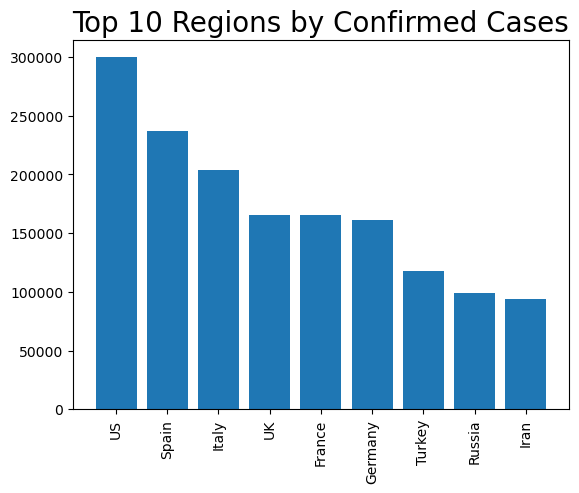

In [107]:
top10 = data.sort_values(by = 'Confirmed', ascending = False).head(10)
plt.bar(top10['Region'], top10['Confirmed'])
plt.xticks(rotation = 90)
plt.title('Top 10 Regions by Confirmed Cases', size = 20)

#### Overall United States has much more cases than the other countries in the chart.

### Create a scatter plot comparing Confirmed cases and Deaths.

<function matplotlib.pyplot.show(close=None, block=None)>

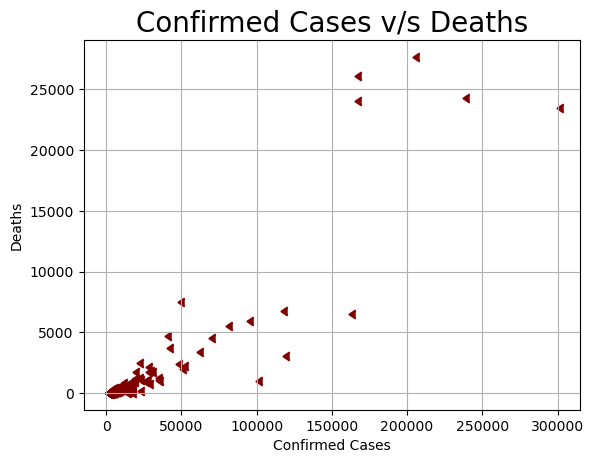

In [110]:
plt.scatter(data=data, x='Confirmed',y='Deaths', c='Maroon',marker=4)
plt.xlabel('Confirmed Cases')
plt.ylabel('Deaths')
plt.title('Confirmed Cases v/s Deaths',size = 20)
plt.grid()
plt.show

#### Overall there is a positive relationship—when confirmed cases rise, deaths tend to rise as well.